In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Linear SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

# RBF SVM
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

print("Linear SVM accuracy:", svm_linear.score(X_test, y_test))
print("RBF SVM accuracy:", svm_rbf.score(X_test, y_test))


Linear SVM accuracy: 0.956140350877193
RBF SVM accuracy: 0.9824561403508771


In [2]:
from sklearn.neighbors import KNeighborsClassifier

for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    print(f"KNN (k={k}) accuracy:", knn.score(X_test, y_test))


KNN (k=3) accuracy: 0.9473684210526315
KNN (k=5) accuracy: 0.9473684210526315
KNN (k=7) accuracy: 0.9473684210526315


In [5]:
for model in [svm_linear, svm_rbf]:
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{model.kernel} SVM CV accuracy:", scores.mean())
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5)
    print(f"KNN (k={k}) CV accuracy:", scores.mean())


linear SVM CV accuracy: 0.9455364073901569
rbf SVM CV accuracy: 0.9121720229777983
KNN (k=3) CV accuracy: 0.9191429902189101
KNN (k=5) CV accuracy: 0.9279459711224964
KNN (k=7) CV accuracy: 0.9261760596180716


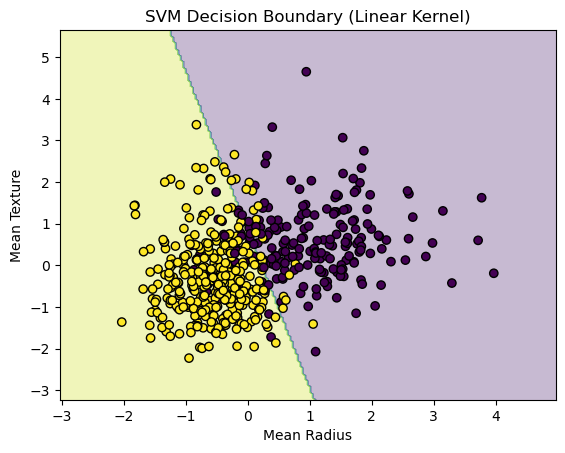

In [6]:
import matplotlib.pyplot as plt
import numpy as np

X2 = data.data[:, :2]  # first two features
y2 = data.target

X2 = scaler.fit_transform(X2)

svm2d = SVC(kernel='linear').fit(X2, y2)

# Plot decision boundary
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = svm2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:, 0], X2[:, 1], c=y2, edgecolors='k')
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("SVM Decision Boundary (Linear Kernel)")
plt.show()


In [7]:
from sklearn.datasets import load_digits

digits = load_digits()
X, y = digits.data, digits.target

knn = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(knn, X, y, cv=5)
print("KNN on digits dataset CV accuracy:", scores.mean())


KNN on digits dataset CV accuracy: 0.9627282575054161


In [8]:
for kernel in ['linear', 'poly', 'rbf']:
    svm = SVC(kernel=kernel)
    scores = cross_val_score(svm, X, y, cv=5)
    print(f"SVM ({kernel}) CV accuracy:", scores.mean())


SVM (linear) CV accuracy: 0.9476973073351903
SVM (poly) CV accuracy: 0.9705106778087279
SVM (rbf) CV accuracy: 0.9632838130609718
